In [17]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

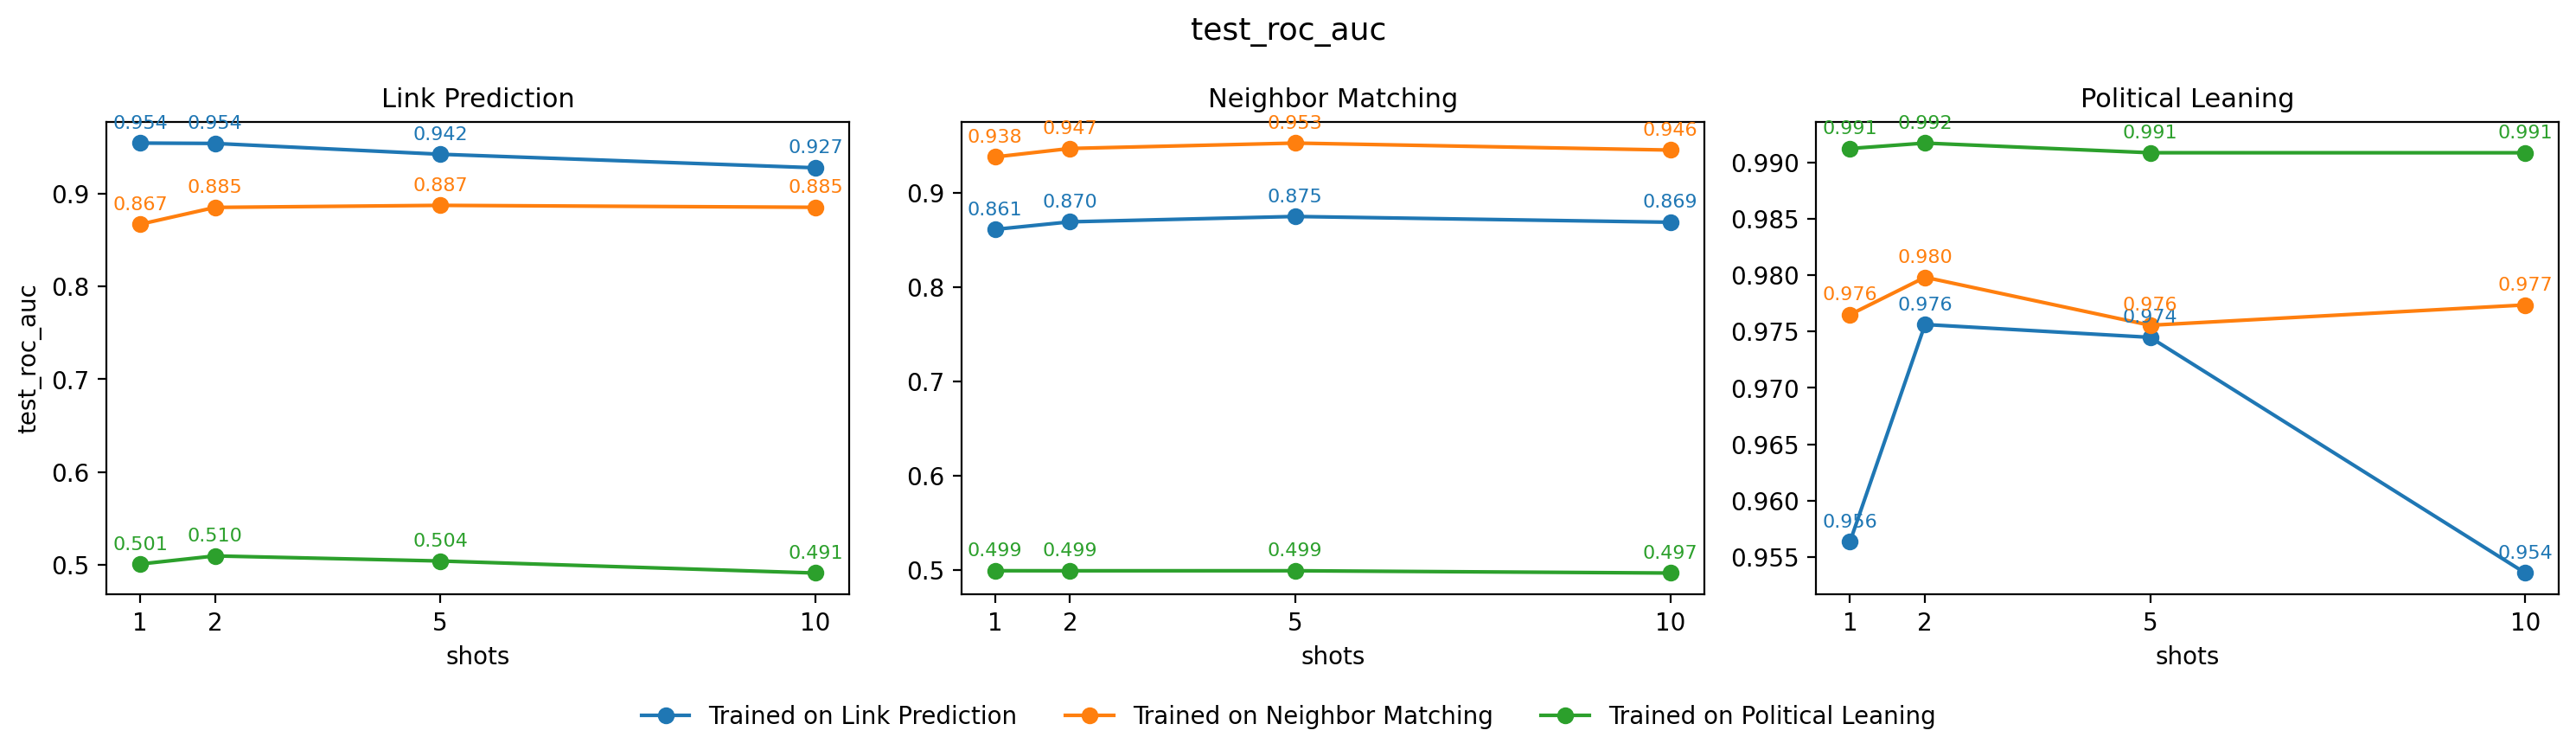

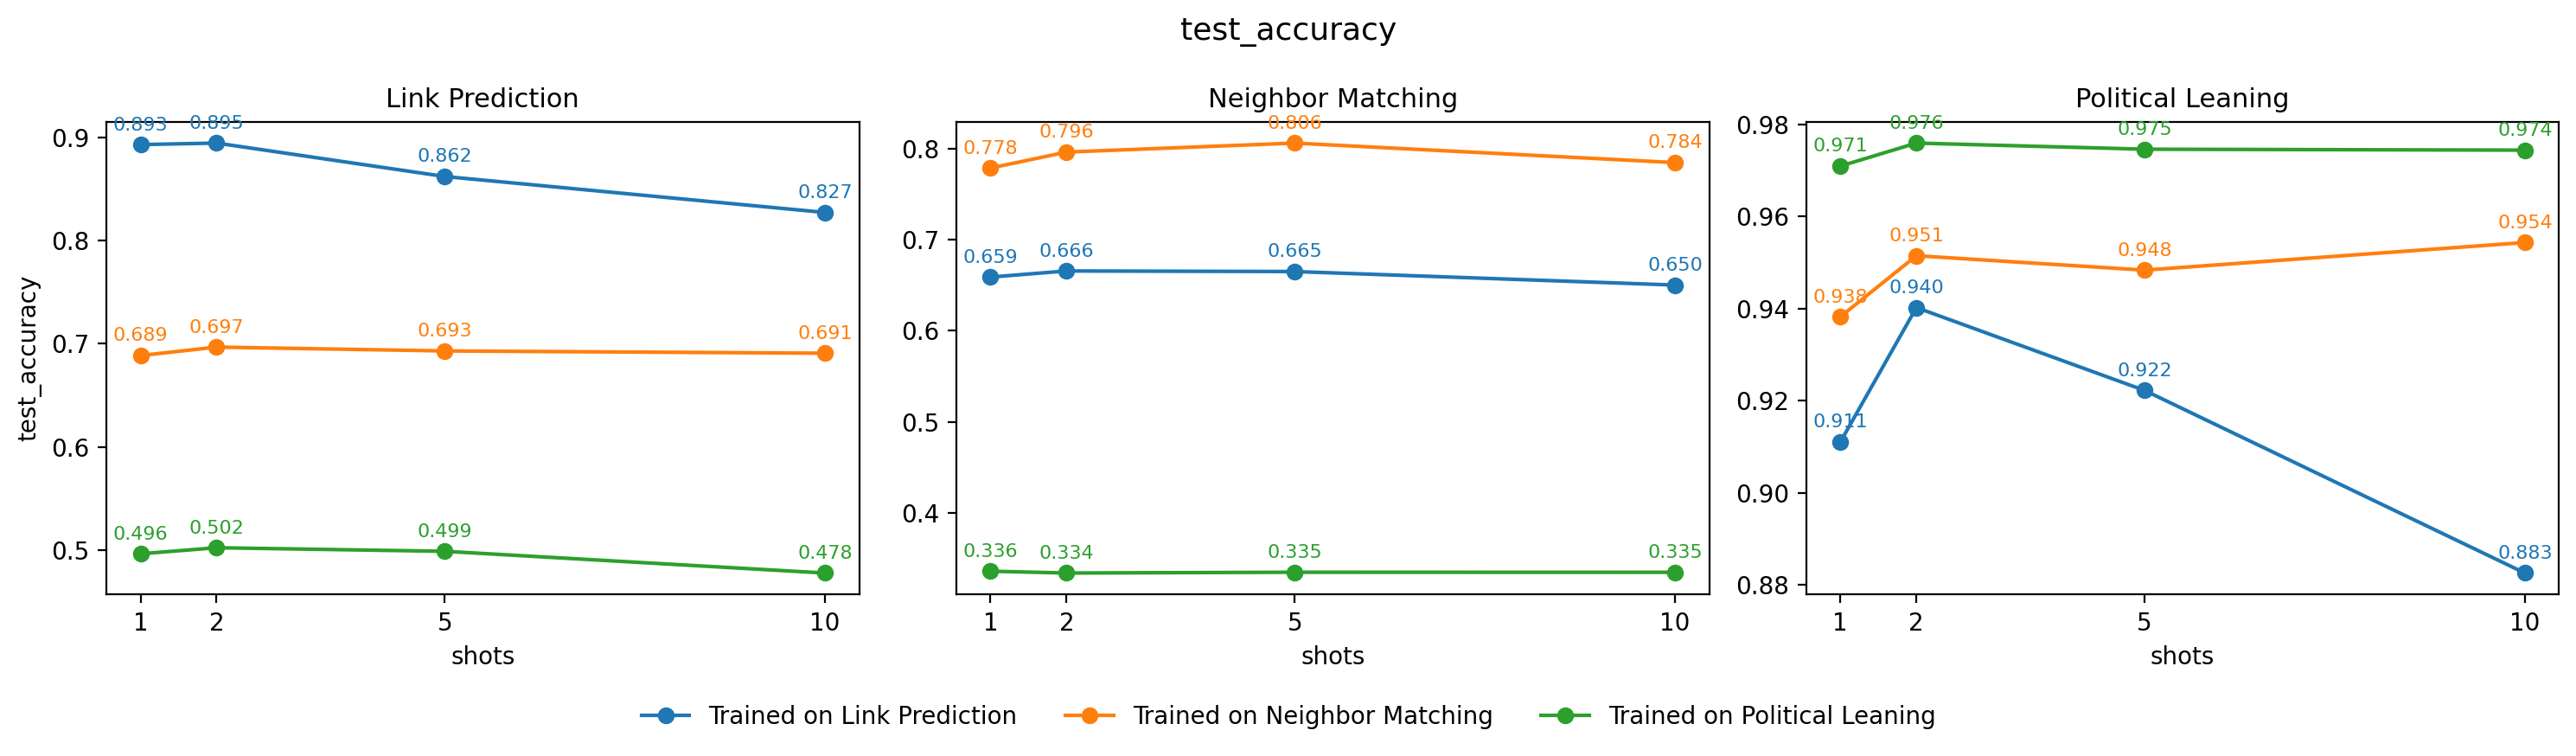

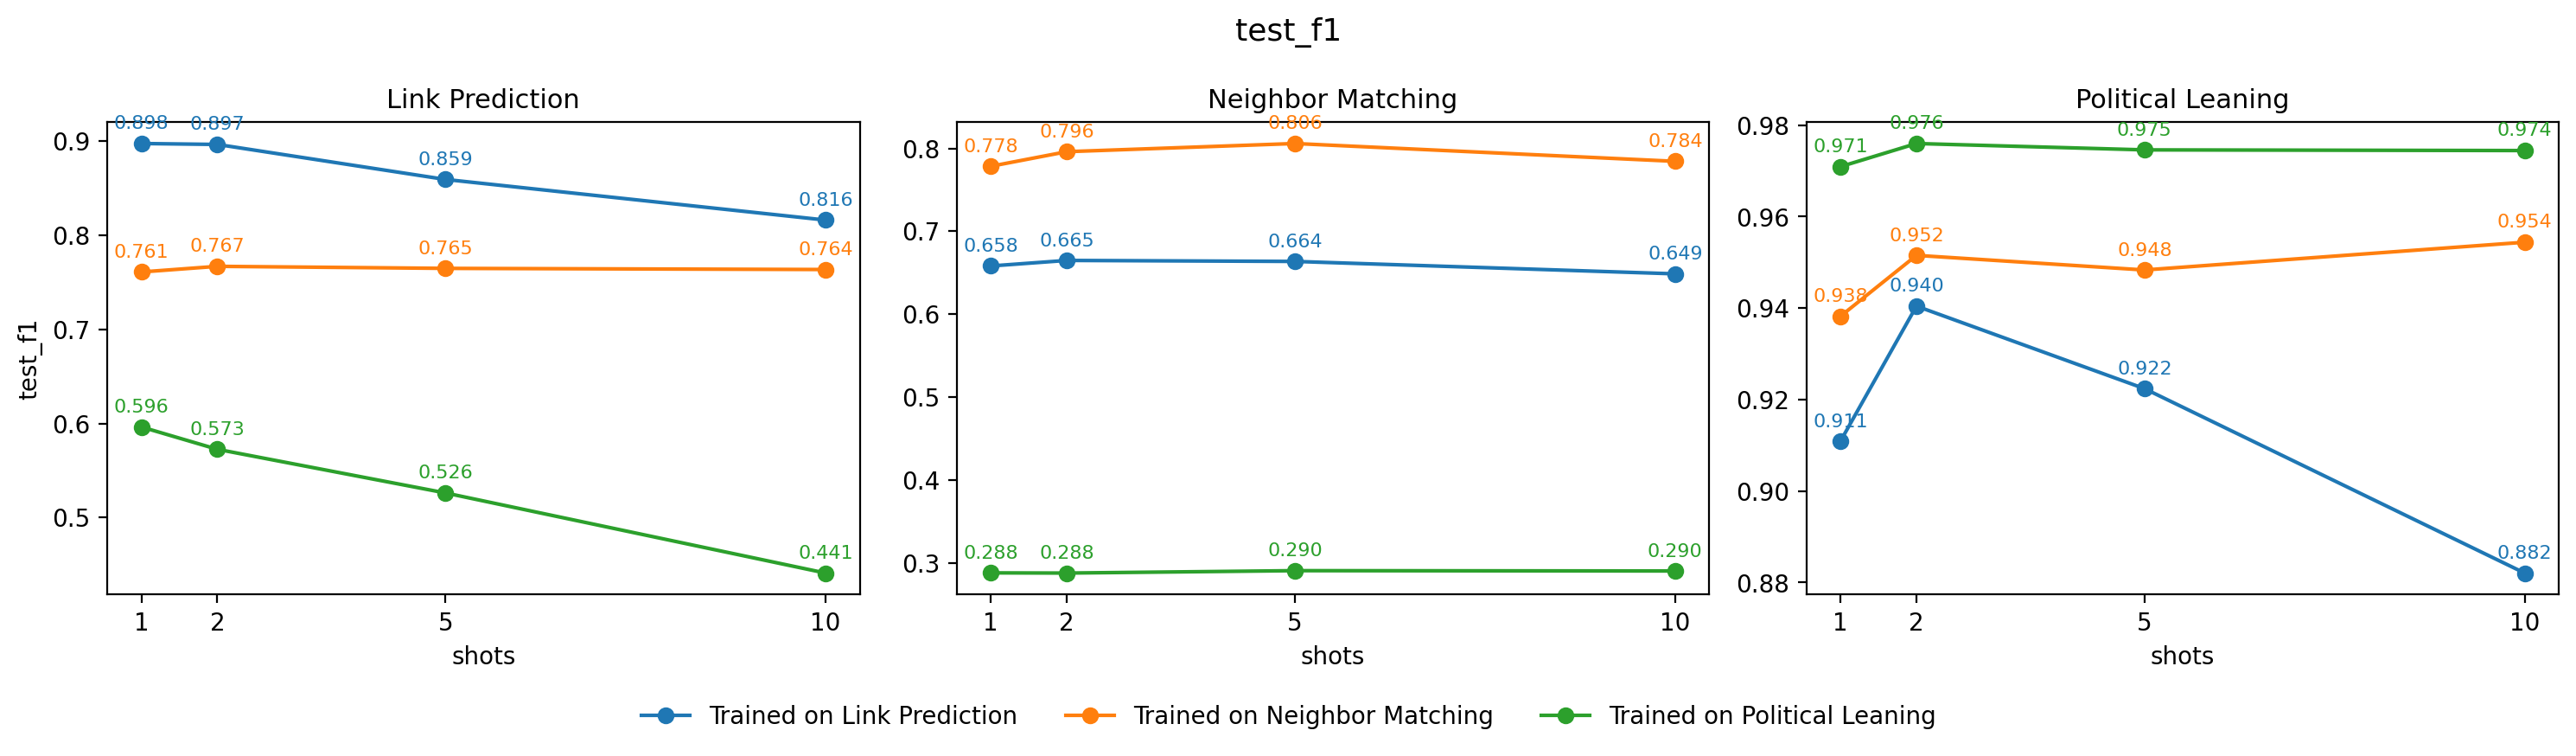

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_metrics(df, metrics=("test_roc_auc", "test_accuracy", "test_f1"),
                 x="shots", hue="train_task_name", col="eval_task_name"):

    tasks = df[hue].unique()
    evals = df[col].unique()
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = dict(zip(tasks, colors))

    for metric in metrics:
        fig, axes = plt.subplots(1, len(evals), figsize=(5 * len(evals), 4), sharey=False)
        if len(evals) == 1:
            axes = [axes]

        for ax, ev in zip(axes, evals):
            for task in tasks:
                sub = df[(df[col] == ev) & (df[hue] == task)].sort_values(x)
                ax.plot(sub[x], sub[metric], marker="o", label=task, color=color_map[task])
                for _, row in sub.iterrows():
                    ax.annotate(f"{row[metric]:.3f}", (row[x], row[metric]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=8, color=color_map[task])

            ax.set_title(ev, fontsize=11)
            ax.set_xlabel(x)
            # ax.set_ylim((0,1))
            ax.set_ylabel(metric if ax == axes[0] else "")
            ax.xaxis.set_major_locator(ticker.FixedLocator(df[x].unique()))

        handles, labels = axes[0].get_legend_handles_labels()
        labels = [f'Trained on {x}' for x in labels]
        fig.legend(handles, labels, loc="lower center", ncol=len(tasks),
                   bbox_to_anchor=(0.5, -0.08), frameon=False)
        fig.suptitle(metric, fontsize=13, fontweight="500")
        plt.tight_layout()
        plt.show()


df = pd.read_csv('/Users/philipp/Downloads/icl_train1_results.csv')
plot_metrics(df)

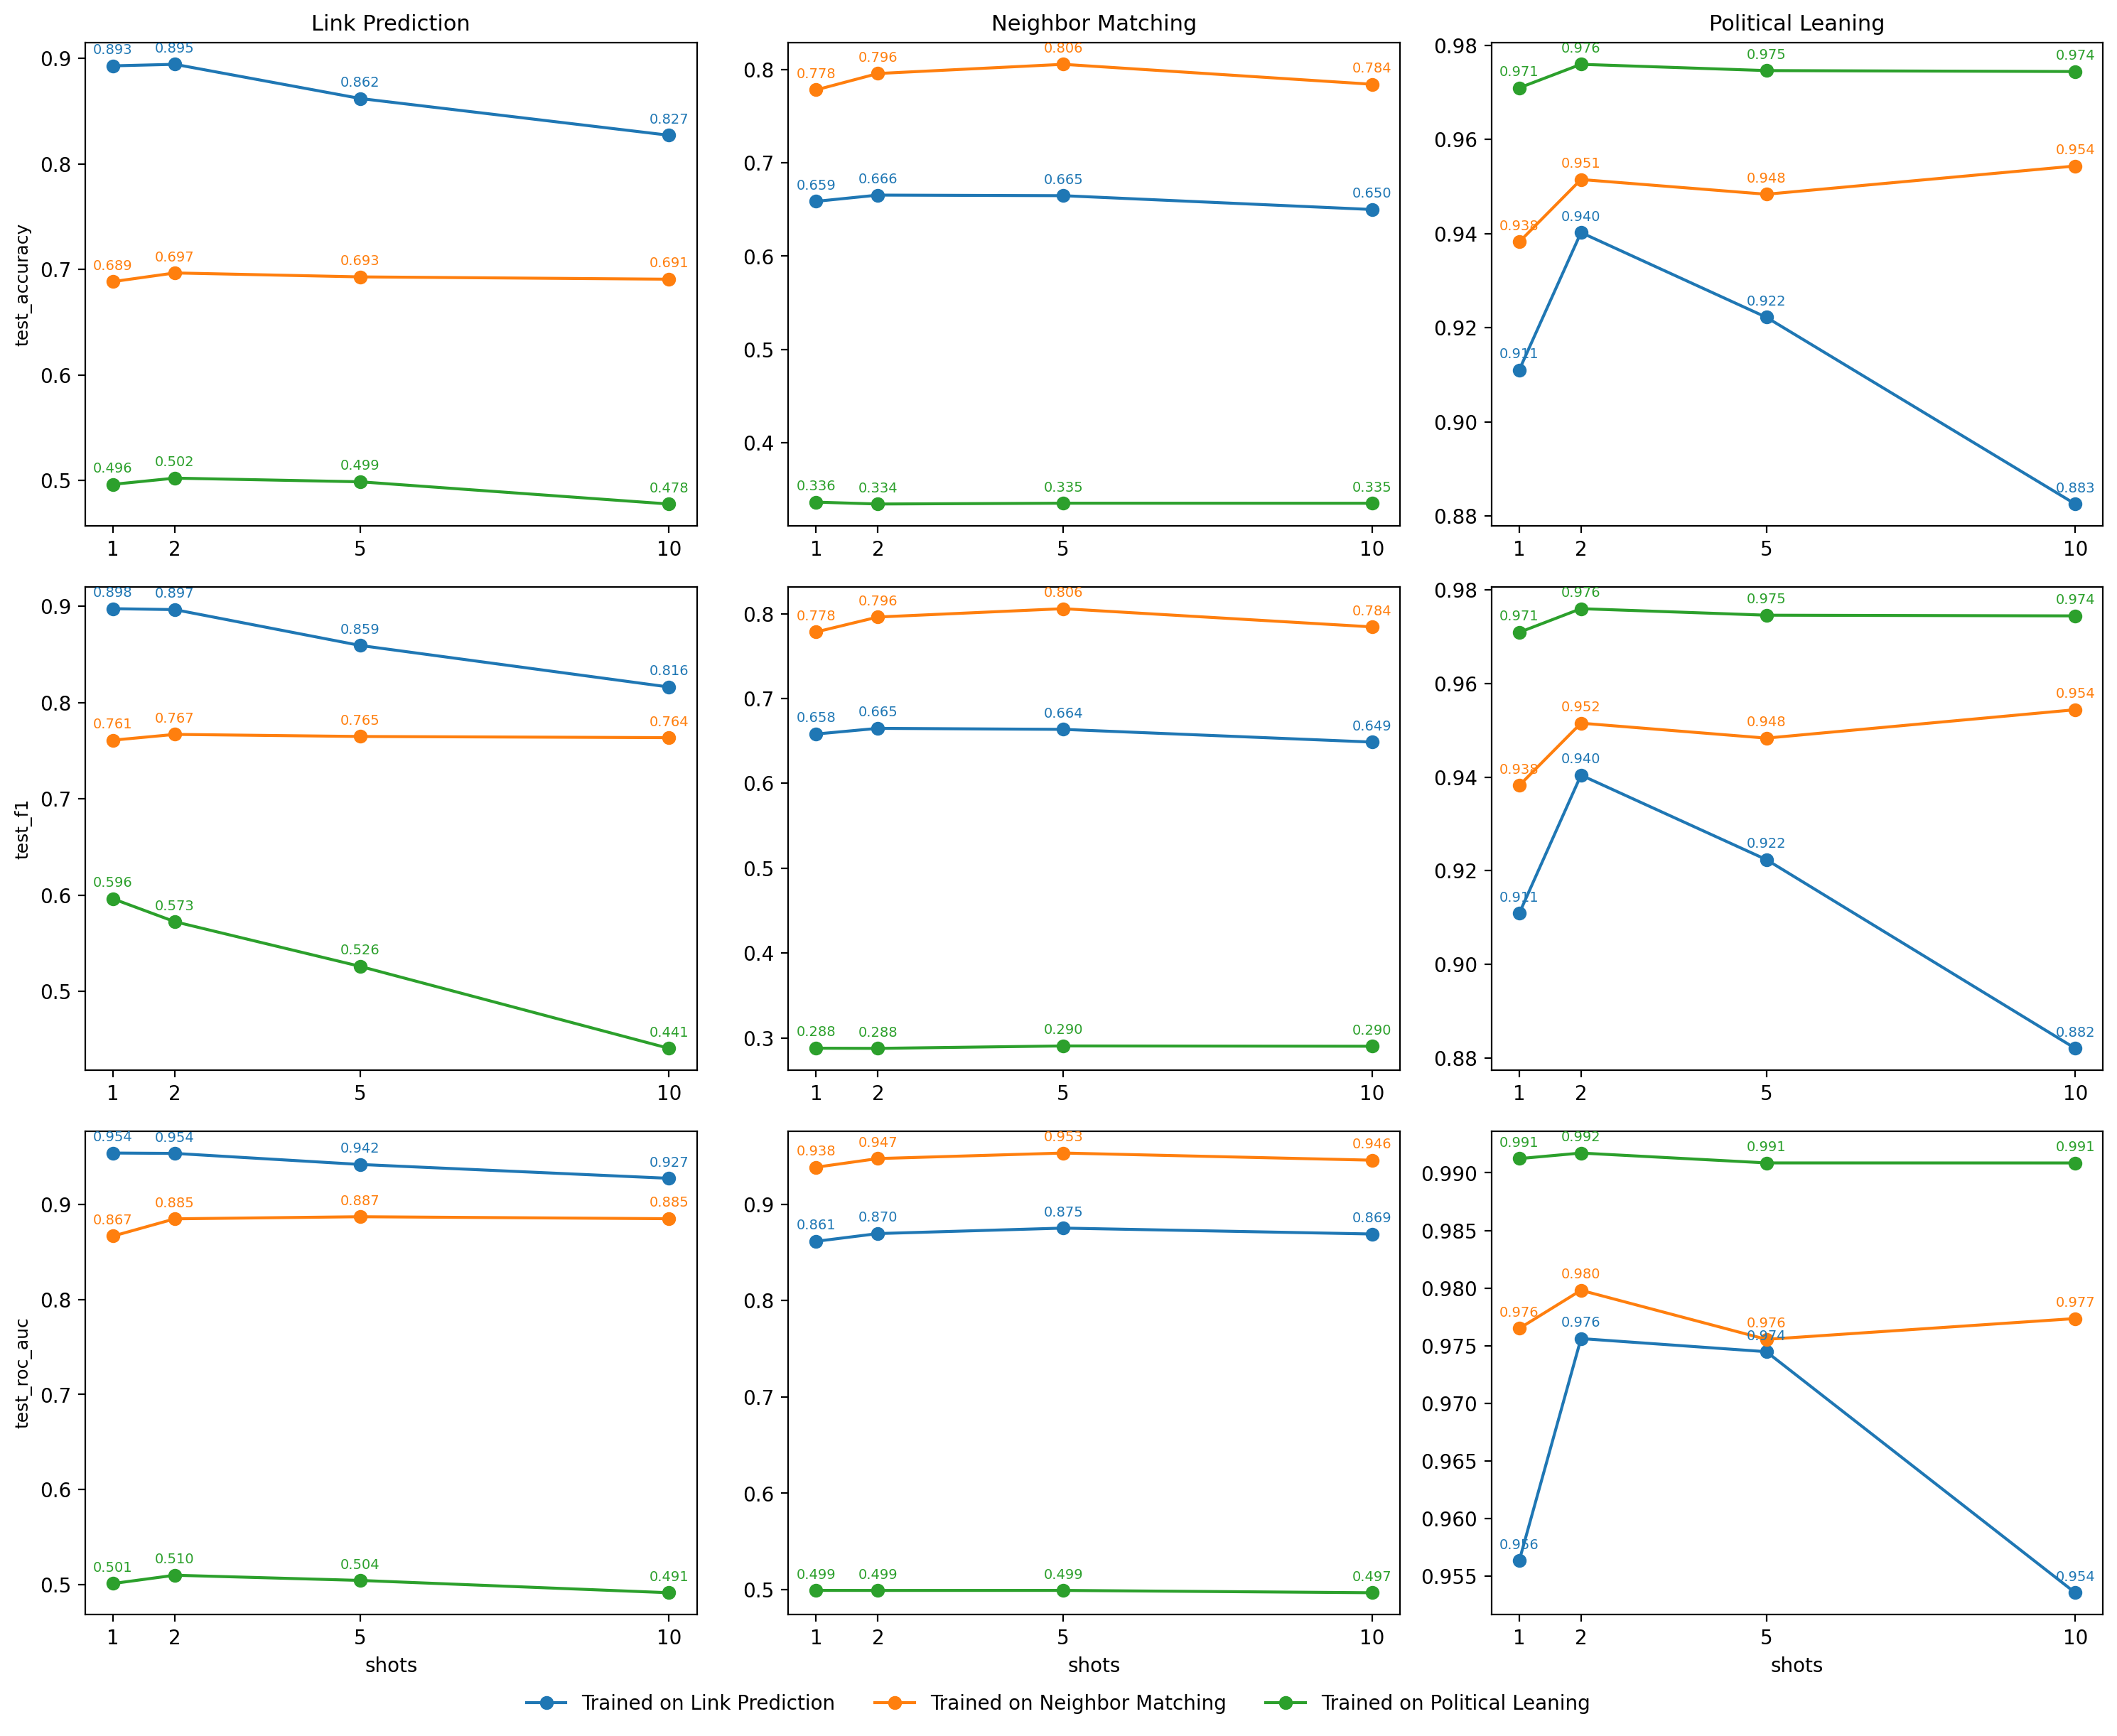

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_all(df, metrics=("test_accuracy", "test_f1", "test_roc_auc"),
             x="shots", hue="train_task_name", col="eval_task_name"):

    tasks = df[hue].unique()
    evals = df[col].unique()
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = dict(zip(tasks, colors))

    fig, axes = plt.subplots(len(metrics), len(evals),
                             figsize=(5 * len(evals), 4 * len(metrics)),
                             sharey=False)

    for r, metric in enumerate(metrics):
        for c, ev in enumerate(evals):
            ax = axes[r][c]
            for task in tasks:
                sub = df[(df[col] == ev) & (df[hue] == task)].sort_values(x)
                ax.plot(sub[x], sub[metric], marker="o", label=task, color=color_map[task])
                for _, row in sub.iterrows():
                    ax.annotate(f"{row[metric]:.3f}", (row[x], row[metric]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=7, color=color_map[task])

            if r == 0:
                ax.set_title(ev, fontsize=11)
            if c == 0:
                ax.set_ylabel(metric, fontsize=9)
            ax.set_xlabel(x if r == len(metrics) - 1 else "")
            ax.xaxis.set_major_locator(ticker.FixedLocator(df[x].unique()))

    handles, labels = axes[0][0].get_legend_handles_labels()
    labels = [f'Trained on {x}' for x in labels]
    fig.legend(handles, labels, loc="lower center", ncol=len(tasks),
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.tight_layout()
    plt.show()

plot_all(df)

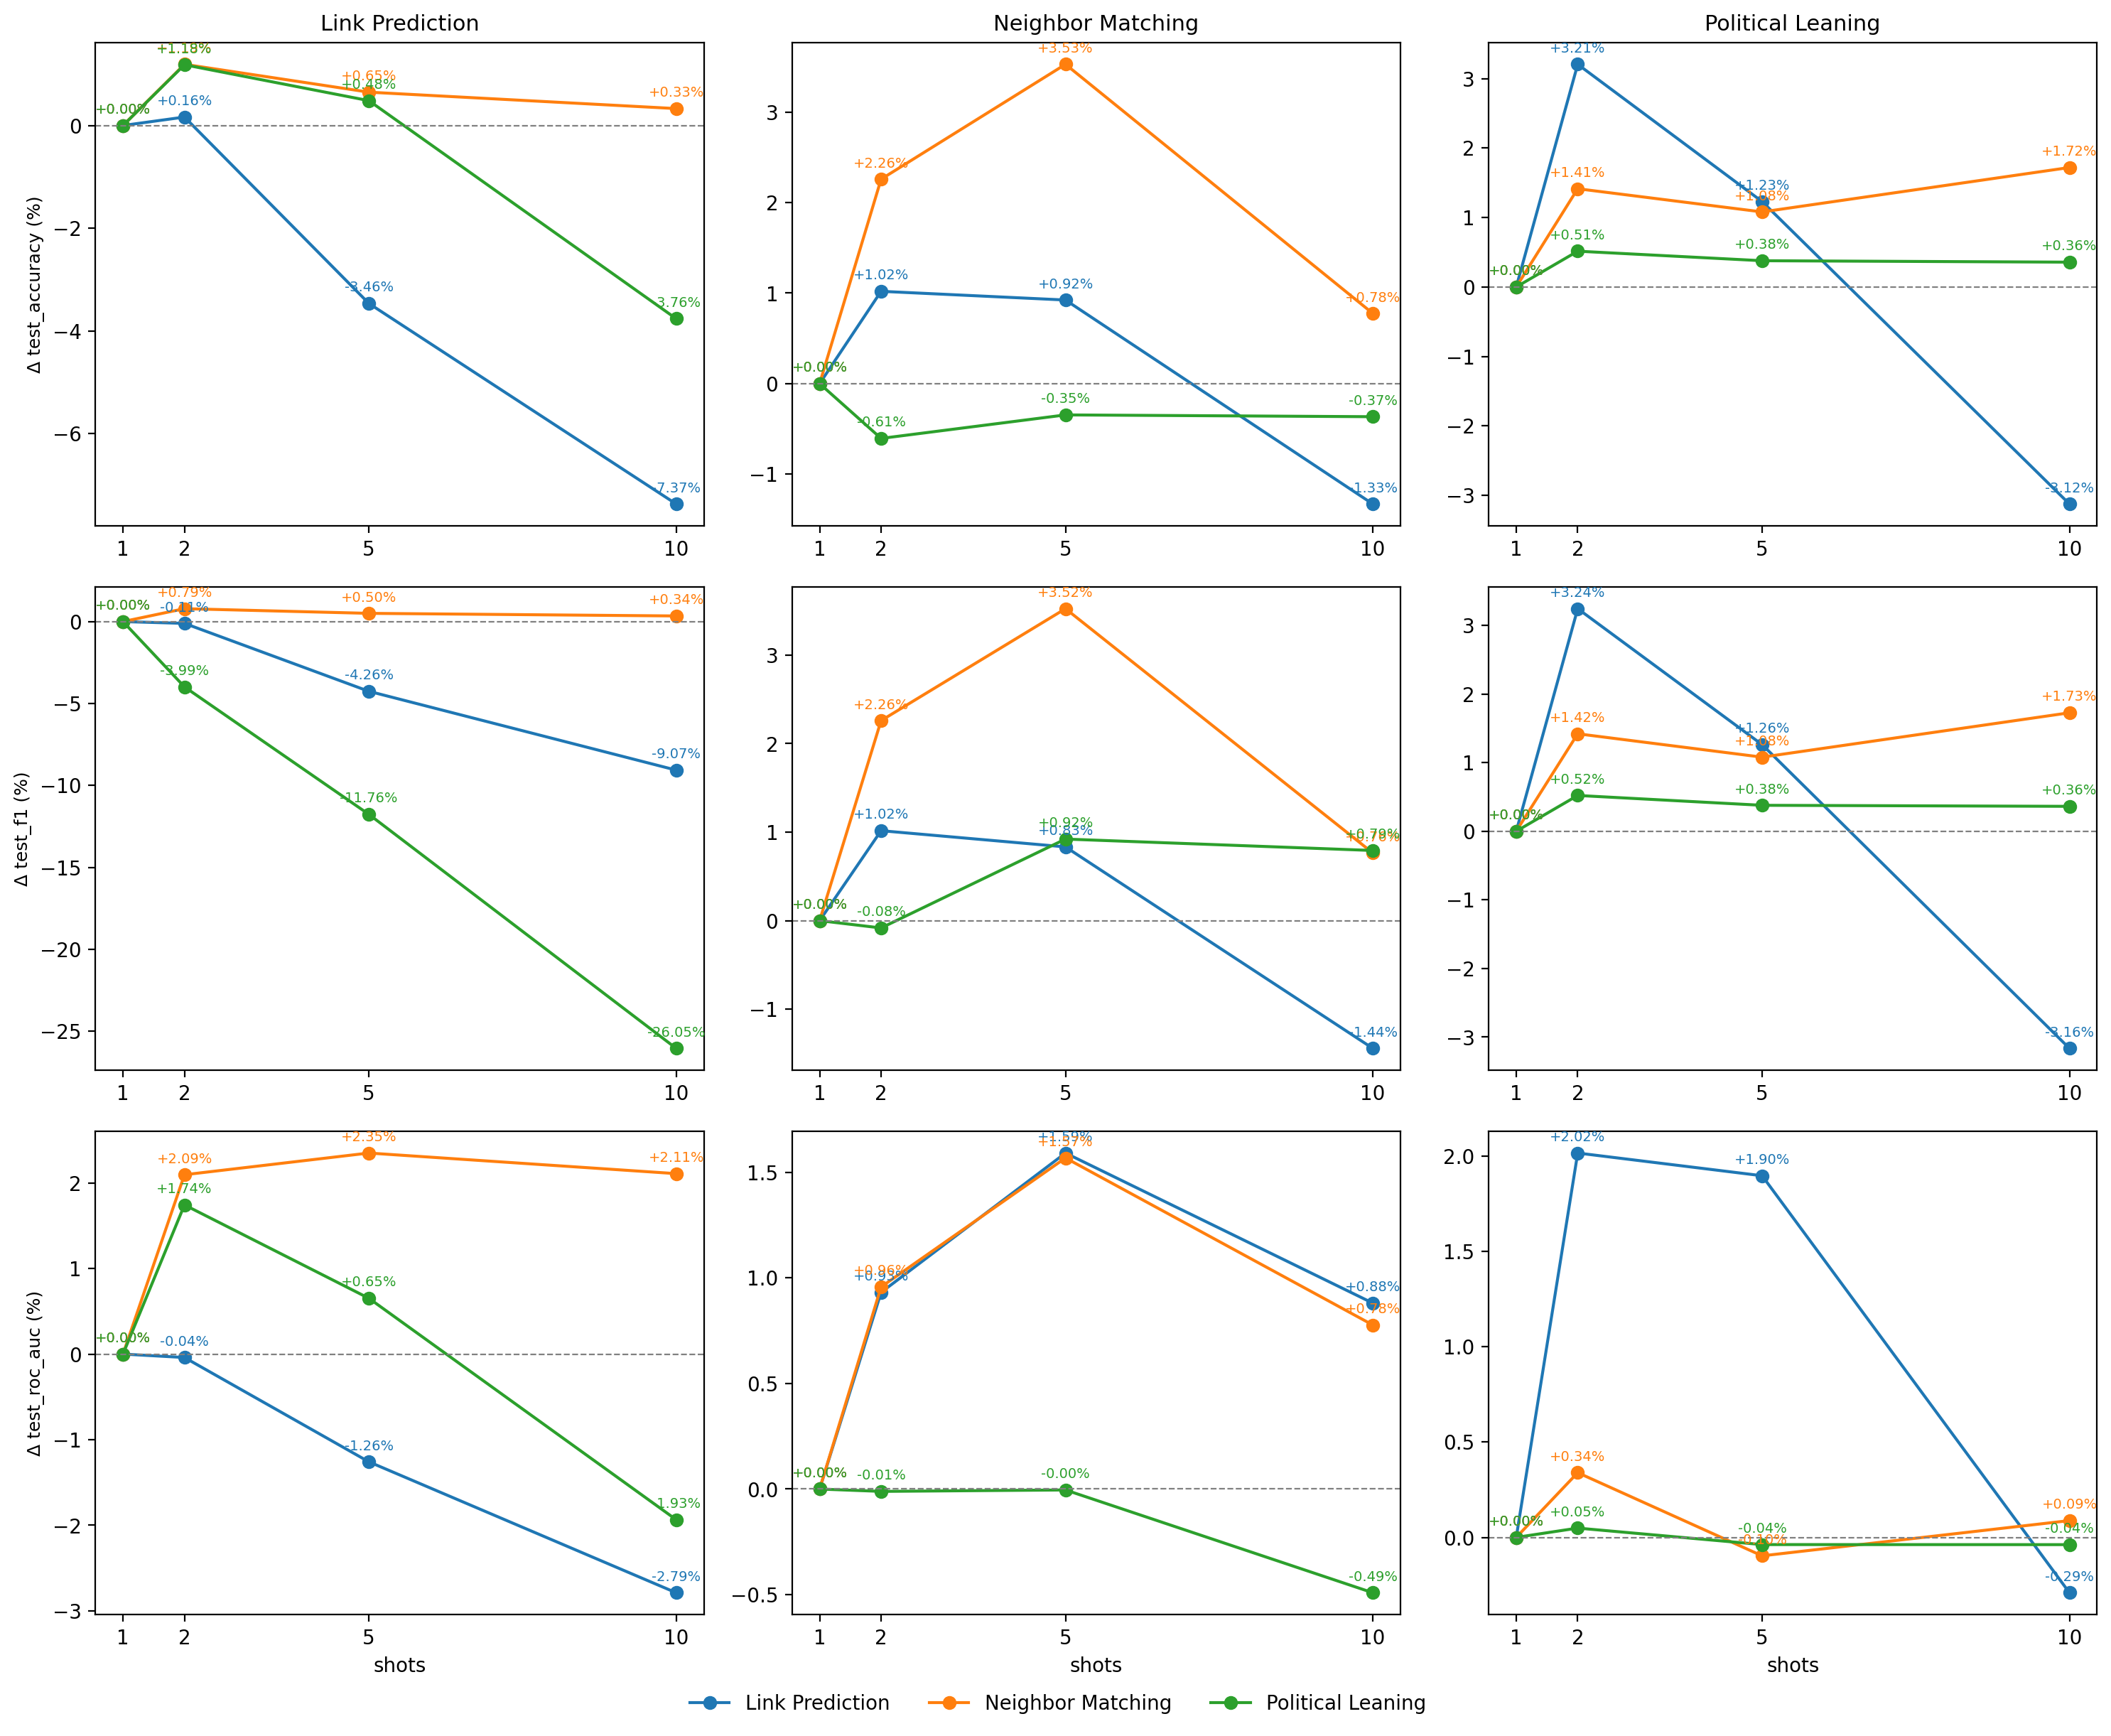

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_relative_change(df, metrics=("test_accuracy", "test_f1", "test_roc_auc"),
                          x="shots", hue="train_task_name", col="eval_task_name"):

    tasks = df[hue].unique()
    evals = df[col].unique()
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = dict(zip(tasks, colors))

    fig, axes = plt.subplots(len(metrics), len(evals),
                             figsize=(5 * len(evals), 4 * len(metrics)),
                             sharey=False)

    for r, metric in enumerate(metrics):
        for c, ev in enumerate(evals):
            ax = axes[r][c]
            for task in tasks:
                sub = df[(df[col] == ev) & (df[hue] == task)].sort_values(x).copy()
                baseline = sub[metric].iloc[0]
                sub["rel_change"] = (sub[metric] - baseline) / baseline * 100

                ax.plot(sub[x], sub["rel_change"], marker="o", label=task, color=color_map[task])
                for _, row in sub.iterrows():
                    ax.annotate(f"{row['rel_change']:+.2f}%", (row[x], row["rel_change"]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=7, color=color_map[task])

            ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            if r == 0:
                ax.set_title(ev, fontsize=11)
            if c == 0:
                ax.set_ylabel(f"Δ {metric} (%)", fontsize=9)
            ax.set_xlabel(x if r == len(metrics) - 1 else "")
            ax.xaxis.set_major_locator(ticker.FixedLocator(df[x].unique()))

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(tasks),
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.tight_layout()
    plt.show()

plot_relative_change(df)